## Notebook for testing gridded stat and anomaly methods

### Import libraries and initiate utilities routines

In [11]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
import xarray as xr
import os
from datetime import datetime
import matplotlib.pyplot as plt
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

current_path = Path.cwd()

# Search for the utilities directory
for parent in current_path.parents:
    candidate = parent / "utilities"
    if candidate.is_dir():
        sys.path.insert(0, str(parent))
        break
else:
    raise FileNotFoundError("Could not locate 'utilities' directory in parent paths.")

from utilities import init_notebook_environment
from utilities import get_dataset_products,get_prod_files,dataset_defaults,file_parser
from utilities import get_nc_prod,product_defaults,netcdf_product_defaults
from utilities import run_stats_pipeline,build_stats_map
from utilities import get_file_dates, get_period_info, get_period_sets, get_period_dates, extract_period_code, generate_periods


env = init_notebook_environment(verbose=False)


## Definitions
**Dataset** - The source of the original data (e.g. GLORYS, OC-CCI, MOM6, ACSPO)  
**Version** - The dataset version (e.g. V6.0)  
**Prod** - Specific product(s) within datasets  
**Period** - The temporal resolution (e.g. daily, weekly, monthly, seasonal, annual)  
**Climatology Period** - The temporal resolution on the climatology (DOY, WEEK, MONTH, SEASON, ANNUAL)  
**Subset** - A predefined area of interest to subset the global data 
* NES - Northeast Shelf [lat_min:34.0, lat_max:47.0, lon_min:-79.0, lon_max:-61.0 ]
* NWA - Northwest Atlantic (i.e. East Coast) [lat_min:22.5, lat_max:48.5, lon_min:-82.5, lon_max:-51.5]  


## Workflow
<img src="StatsWorkflows-20260430.png">


## Stats Pipeline
Headless Command Line Interface (CLI) script that can be incorporated into the automated workflows
* Adds the script path & loads the utility scripts
* Parses the input arguments and initiates the Pipeline

    ### Run Stats Pipeline
    Runs the multi-product, multi-period stats pipeline either sequential or in parallel

    ### Build Stats Map
    * Finds the input files
    * Generate the period map
    * Create the output directory & file names
    * Compare inputs and outputs to determine if the file exists and/or needs to be recreated

        ### Get Prod Files
        Retrieves NetCDF files for a specified product from a structured dataset directory (defaults to daily ).
<img src="RunStatsPipeline-20260430.png">

## EDAB Utilities
https://github.com/NEFSC/READ-EDAB-Utilities-py
* dataset_utilities
* date_utilities
* file_utilities
* function_utilities
* mapping_utilities
* metadata_utilities
* **period_utilities**
* product_utilities
* **statanom_utilities**

### Calculations
* calc_annual_pp
* calc_daylength
* calc_mapped_pixel_area
* calc_primprod

### Get Product Defaults 
* "EDAB" product defaults
* netcdf (i.e. source data) product defaults

In [ ]:
product_defaults()

In [ ]:
netcdf_product_defaults()

### Get Product files

In [ ]:
get_prod_files('CHL')

In [ ]:
get_prod_files('CHL',dataset='GLOBCOLOUR')

In [ ]:
get_prod_files('BTEMP')

In [ ]:
get_prod_files('CHL',period='M',map_region='NES')

In [ ]:
get_prod_files('CHL',getfilepath=True,period='MONTH',map_region='NES')

## Stat Periods
<img src="../StatsPeriods-20260430.png">

In [ ]:
info = get_period_info()

print("Available period codes:")
for p, meta in info.items():
    file_format = meta["file_format"]
    description = meta["description"]
    print(f"{p:5}  {file_format:30}  {description}")

In [ ]:
get_period_info('W')

#### Weekly periods
Weekly period are based on the standardized ISO week format. Week 1 of the 7-day, Monday-to-Sunday, week-based calendar is defined as the week containing the first Thursday of the year, usually containing January 4th. Thus week one of the new calendar year may start in December of the preceeding year and week 52/53 may end in January of the following year.
*  W → a SINGLE ISO week (YYYYWW) 
*  WW → a RANGE of ISO weeks (YYYYWW_YYYYWW)
*  WEEK → a SINGLE CLIMATOLOGY of a week with the year span (WW_YYYY_YYYY)
*  WEEKS → a COMPLETE CLIMATOLOGY series (week 1 to 52) with the year span (WW_YYYY_YYYY)

In [ ]:
pers = [
    "W_201001",
    "W_201101",
    "W_201201",
    "W_201301",
    "W_201401",
    "WW_202101_202152",
    "WEEK_03_2006_2020",
    "WEEKS_2000_2020"
    ]
pds = get_period_dates(pers)

for per, pd in zip(pers, pds):
    print(f"{per} : {pd}")

In [ ]:
info = get_period_info()
periods = info.keys()
for p in periods:
    i = info.get(p)
    print(f"{p} is climatology = {i['is_climatology']}")

### Create periods from a given date range

In [ ]:
start = "19970901"
end = "20260309"
climatology_range = [1991,2020]

d = generate_periods('D',start,end)
d8 = generate_periods('D8',start,end)
dd8y = generate_periods('DD8',start,end,range_by_year=True)
doy = generate_periods('DOY',start,end,climatology_range=climatology_range)
doys = generate_periods('DOYS',start,end,climatology_range=climatology_range)
w = generate_periods('W',start,end)
m = generate_periods('M',start,end)
jfm = generate_periods('JFM',start,end)
annual = generate_periods('ANNUAL',start,end,climatology_range=climatology_range)

print(f"Daily periods: {d[:5]} ... {d[-5:]}")
print(f"8-day periods: {d8[:5]} ... {d8[-5:]}")
print(f"8-day grouped by yearperiods: {dd8y}")
print(f"Daily Climatology: {doy[:5]} ... {doy[-5:]}")
print(f"DOY Climatology: {doys}")
print(f"Weekly periods: {w[:5]} ... {w[-5:]}")
print(f"Monthly periods: {m[:5]} ... {m[-5:]}")
print(f"JFM periods: {jfm[:5]} ... {jfm[-5:]}")
print(f"Annual Climatology: {annual}")

### Create sets of periods based on the input period "files" from above

In [ ]:
doy_perset = get_period_sets('DOY',files=d)
print(f"DOY period sets: {list(doy_perset.keys())}")
doy_perset

### Build Stats Map
<img src="../BuildStatsMap-20260430.png">

In [ ]:
build_stats_map('CHL','M',subset='NES')


#### Process output files in parallel using ProcessPoolExecutor
<img src="../RunStatsPipeline-20260430.png">
    
        with concurrent.futures.ProcessPoolExecutor(parallel_runs=parallel_runs) as executor:
            # Submit all tasks to the pool
            future_to_period = {
                executor.submit(process_single_stat, task, prod, period, verbose, **kwargs): out_period
                for out_period, task in tasks_to_run
            }
        
        # Collect results as they finish (not necessarily in order!)
        for future in concurrent.futures.as_completed(future_to_period):
            out_period = future_to_period[future]
            try:
                success, corrupt_files = future.result()
                if corrupt_files: all_corrupt_inputs.extend(corrupt_files)
                
                if success:
                    successful_tasks.append(out_period)
                    if verbose: print(f"  ✅ [Parallel] Finished {out_period}")
                else:
                    failed_tasks.append(out_period)
            except Exception as e:
                failed_tasks.append(f"{out_period}: {str(e)}")
                print(f"\n❌ [Parallel] Error on {out_period}:\n  ⚠️  {e}")


### Process Single Stat
xarray - https://docs.xarray.dev/en/stable/

<img src="ProcessSingleStat-20260430.png">

### Compute Stats
Default = ['mean', 'min', 'max', 'median', 'std', 'sum', 'var', 'count']

### Add Attributes
* Global
* Product

In [ ]:
xr.open_mfdataset(get_prod_files('CHL',period='M',map_region='NES'))

In [ ]:
ds = xr.open_mfdataset(get_prod_files('CHL',period='M',map_region='NES'))
da = ds.CHL_mean
da

### Global OC-CCI vs Local Stats (CHL January 1998)
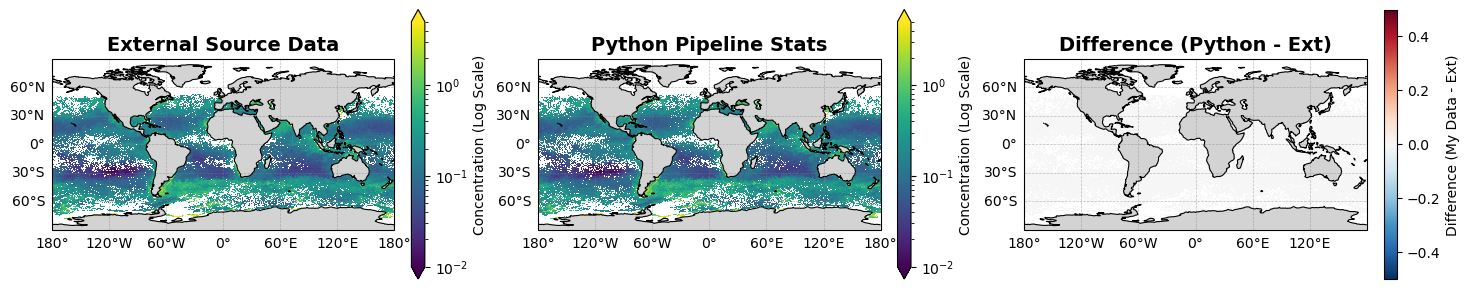

### Global OC-CCI NES subset vs Local Stats (CHL July 1998)
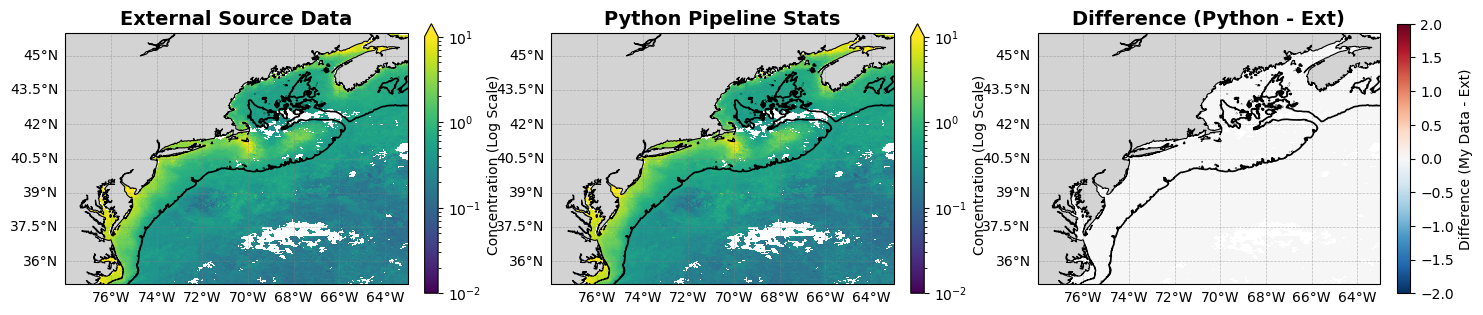

### IDL Stats vs Python Stats (CHL January 1998 - Week 1)
Note the weeks have different start dates
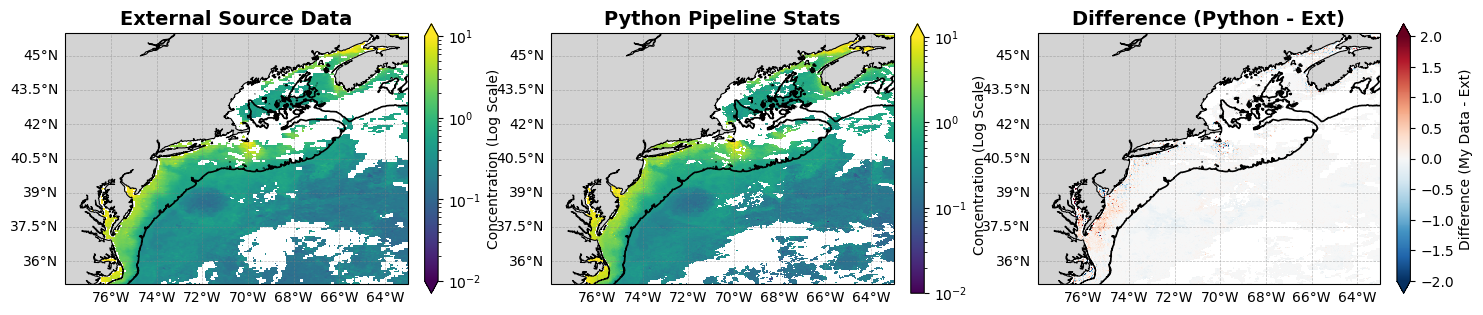

### IDL Stats vs Python Stats (SST - January 2022)
Note, the IDL data have been regridded multiple times
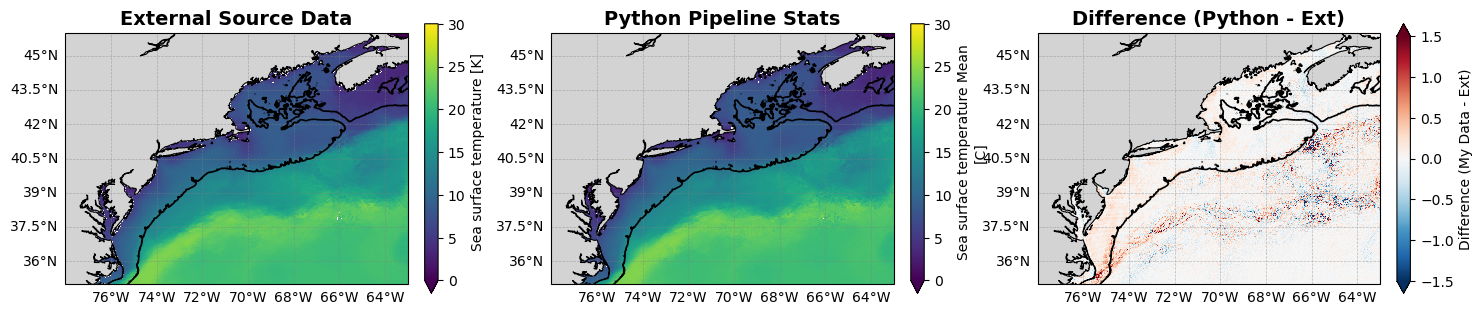

### Pre-Process Datasets (special cases)
* Phytoplankton Size Class
* Convert K to C
* Fronts (TBD)

In [ ]:
xr.open_mfdataset(get_prod_files('PSC'))

### Calculate absolute PSC concentration from the PSC fractions
            ds['PSC_micro'] = ds['PSC_fmicro'] * ds['CHL']
            ds['PSC_nano']  = ds['PSC_fnano']  * ds['CHL']
            ds['PSC_pico']  = ds['PSC_fpico']  * ds['CHL']
            
            # Explicitly define which variables to run stats on
            target_vars = [
                'PSC_fmicro', 'PSC_fnano', 'PSC_fpico', 
                'PSC_micro', 'PSC_nano', 'PSC_pico', 'CHL'
            ]

In [ ]:
xr.open_mfdataset(get_prod_files('PSC',period='M',map_region='NES'))

### Climatologies

In [ ]:
files = get_prod_files('SST',period='MONTH',map_region='NES')
xr.open_mfdataset(files)

In [ ]:
files = get_prod_files('CHL',period='M',map_region='NES')
get_period_sets('MONTH', files=files)

In [ ]:
get_prod_files('SST')

In [ ]:
run_stats_pipeline("SST",periods="M",subset='NES',parallel_runs=4)

In [ ]:
ds = xr.open_dataset('/Users/kimberly.hyde/Documents/nadata/DATASETS/OCCCI/V6.0/PRODUCTS/NES_4KM_MONTHLY/PSC/M_199801-OCCCI-PSC-NES-STATS.nc')
da = ds.PSC_micro_median
ds

In [ ]:
files = get_prod_files('CHL')
fp = file_parser(files[0])
fp

In [ ]:
files = get_prod_files('SST')
ds = xr.open_mfdataset(files)
ds

In [ ]:
files = get_prod_files('SST',period='M',map_region='NES')
ds = xr.open_mfdataset(files)
da = ds.SST_M_mean
ds

In [ ]:
f = get_prod_files('SST',dataset='CORALSST')
ds = xr.open_mfdataset(f)
ds

In [ ]:
get_nc_prod('CORALSST','SST')

In [ ]:
# --- Quick Test Script ---
prod = "CHL"
per  = "M"  # Monthly Mean
subset = "NES"
dataset = 'OCCCI'

run_stats_pipeline(prod,periods=per,subset=subset,dataset=dataset,verbose=True,debug=False)

In [ ]:
base = ['M_200009','M_200010']
extract_period_code('MONTH_02_2000_2009')

In [ ]:
run_stats_pipeline('SST',periods=['M'],subset='NES',verbose=True,debug=False)

In [ ]:
files = get_prod_files('SST')
fp = file_parser(files[0])
fp[0]['dataset']

In [ ]:
sm = build_stats_map('SST','M')
sm[0][0]


In [ ]:
# --- Quick Test Script ---
prod = "SST"
per  = "M"  # Monthly Mean
subset = "NES"

print(f"🧪 Testing Pipeline Discovery for {prod}...")

try:
    # 1. Test Directory Resolution
    out_dir = get_prod_files(prod, period=per, map=subset, getfilepath=True)
    print(f"✅ Resolved Output Dir: {out_dir}")

    # 2. Test Map Building
    # Set overwrite=True to force 'is_up_to_date' to False for testing
    s_map = build_stats_map(prod, per, subset=subset, overwrite=True, verbose=True)

    if s_map:
        first_key = list(s_map.keys())[0]
        sample = s_map[first_key]
        print(f"\n📝 Sample Task Details for {first_key}:")
        print(f"   • Output Path: {sample['output']}")
        print(f"   • Input Count: {len(sample['inputs'])} files")
        print(f"   • Needs Update: {not sample['is_up_to_date']}")
    else:
        print("❌ Test Failed: No tasks generated.")

except Exception as e:
    print(f"💥 Test Crashed: {e}")

In [ ]:
stats_map = build_stats_map("SST", "M")
#stats_map
#pm = stats_map['period_map']
#output_periods = list(stats_map["output"].keys())
#output_periods
all_outputs = [info['output'] for info in stats_map.values()]
all_outputs[:3]

#for period, info in pm.items():
#    print(period, info["input_files"])


In [ ]:
get_prod_files('SST')

In [ ]:
path = get_prod_files('SST', period='M', getfilepath=True)


In [ ]:
run_stats_pipeline("SST")

## Demo for PERIOD functions

In [ ]:
# Determine if a period code is a climatology period
from utilities import get_period_info
info = get_period_info()
periods = info.keys()
for p in periods:
    i = info.get(p)
    print(f"{p} is climatology = {i['is_climatology']}")

In [ ]:
# Find files and dates, then get period sets for Months
from utilities import get_dates,get_period_sets, get_period_dates

dates = get_dates([2020,2025])
get_period_sets('W',dates=dates)


In [ ]:
get_period_dates('M_202001')

In [ ]:

perdates = get_period_dates(sets)
perdates
#for a, pd in zip(sets, perdates):
#    print("Week:",a,pd)

In [ ]:
# Find files and dates, then get period sets for SEA
from utilities import get_period_sets
files = get_prod_files("CHL")
dates = get_file_dates(files)
start_dates = [start for start, _ in dates]

sets = get_period_sets('SEA',dates=start_dates)

for a in sets:
    print("SEA periods:",a)

In [ ]:
# Get the dates from the input periods
from utilities import get_period_dates

files = ["D_20250926",
         "DD_20250926_20251231",
         "DOY_023_2020_2025",
         "DD3_20250310_20250312",
         "D8_20250101_20250108",
         "W_202301",
         "WW_202501_202552",
         "WEEK_22_2020_2025",
         "M_202204",
         "MM_202501_202612",
         "MM3_202501_202512",
         "MONTH_11_2020_2025",
         "A_2025",
         "ANNUAL_2020_2025",
         "Y_2025",
         "YY_2020_2025",
         "YEAR_2020_2025"
         ]

#g = get_period_dates(files)
for f in files:
    print(f"{f}: {get_file_dates([f])}")

dates = get_file_dates(files)

date_format="%Y%m%d"
valid = [
        (datetime.strptime(s, date_format), datetime.strptime(e, date_format))
        for s, e in dates
        if s != "NA" and e != "NA"
    ]

min_date = min(s for s, _ in valid)
max_date = max(e for _, e in valid)
print (min_date.strftime(date_format), max_date.strftime(date_format))




In [ ]:
run_stats_pipeline(prods='SST',dataset='CORALSST',periods=['M','MONTH'])

### Daily inputs
Create stats from the daily input files
* Monthly
* Weekly
* 3-day running
* 8-day running

In [ ]:
# Get Chlorophyll Files
get_dataset_products('OCCCI')
print(dataset_defaults()['OCCCI'])
dataset_products = get_dataset_products('OCCCI')
print(dataset_products.keys())
files = get_prod_files('CHL',dataset='OCCCI')
ds = xr.open_mfdataset(files)
ds.data_vars.keys()